# EDA — PhysioNet Sepsis 2019

**Nguồn**: PhysioNet/Computing in Cardiology Challenge 2019, CC BY 4.0, không cần credential.

**Nội dung**: 40.336 file `.psv` (1 file = 1 bệnh nhân, chuỗi thời gian theo giờ). Cột quan trọng cho dự án: sinh hiệu, `Bilirubin_total/direct`, `Hct/Hgb/WBC/Platelets`, **`PTT, Fibrinogen`** (đông máu), `Age, Gender`, nhãn **`SepsisLabel`**.

Do khối lượng lớn (40.336 file × nhiều dòng/file), EDA này lấy **mẫu ngẫu nhiên** để phân tích nhanh, kèm thống kê tỷ lệ missing trên toàn bộ tập.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

plt.rcParams['figure.figsize'] = (10, 5)
ROOT = Path(r'D:\AI_08_V1\Data\tabular\physionet_sepsis_2019')

files_a = list((ROOT / 'training_setA').glob('*.psv'))
files_b = list((ROOT / 'training_setB').glob('*.psv'))
print(f'training_setA: {len(files_a)} file | training_setB: {len(files_b)} file | Tổng: {len(files_a)+len(files_b)}')

random.seed(42)
sample_files = random.sample(files_a, 1000) + random.sample(files_b, 1000)
dfs = [pd.read_csv(f, sep='|') for f in sample_files]
big = pd.concat(dfs, ignore_index=True)
print('Số dòng (giờ đo) trong mẫu 2000 bệnh nhân:', big.shape)
big.head()

training_setA: 20336 file | training_setB: 20000 file | Tổng: 40336


Số dòng (giờ đo) trong mẫu 2000 bệnh nhân: (75887, 41)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,88.0,100.0,36.80,124.0,82.0,58.0,12.0,NaN,NaN,26.0,...,9.7,NaN,168.0,67.51,1,0.0,1.0,-750.25,5,0
1,89.5,100.0,36.65,115.0,77.5,57.0,12.5,NaN,3.0,NaN,...,NaN,NaN,NaN,67.51,1,0.0,1.0,-750.25,6,0
2,88.0,100.0,36.70,110.0,75.0,55.0,12.0,NaN,0.0,NaN,...,NaN,NaN,NaN,67.51,1,0.0,1.0,-750.25,7,0
3,77.0,100.0,36.95,107.0,74.0,55.0,12.0,NaN,NaN,NaN,...,NaN,NaN,NaN,67.51,1,0.0,1.0,-750.25,8,0
4,83.0,100.0,37.00,100.0,69.0,52.5,12.0,NaN,NaN,NaN,...,NaN,NaN,NaN,67.51,1,0.0,1.0,-750.25,9,0


Tỷ lệ missing (%) theo cột quan trọng:
Bilirubin_direct    99.8
Fibrinogen          99.4
Bilirubin_total     98.5
PTT                 97.2
Platelets           94.1
WBC                 93.6
Hgb                 92.7
Hct                 91.3
Temp                67.4
HR                  10.4
Age                  0.0
Gender               0.0
SepsisLabel          0.0
dtype: float64


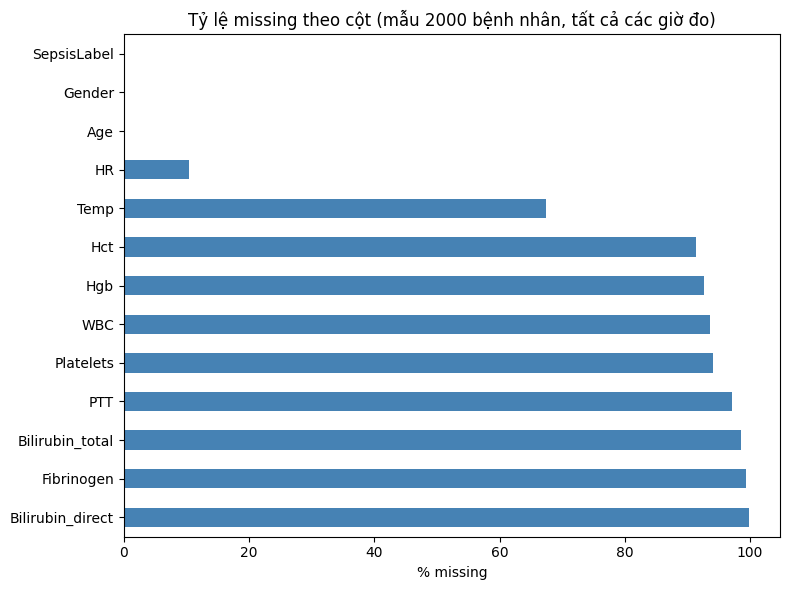

In [2]:
# Tỷ lệ missing theo cột (trên mẫu) — đặc biệt các cột quan trọng cho dự án
key_cols = ['Age', 'Gender', 'HR', 'Temp', 'Hct', 'Hgb', 'WBC', 'Platelets',
            'PTT', 'Fibrinogen', 'Bilirubin_total', 'Bilirubin_direct', 'SepsisLabel']
missing_pct = (big[key_cols].isna().mean() * 100).round(1).sort_values(ascending=False)
print('Tỷ lệ missing (%) theo cột quan trọng:')
print(missing_pct)

missing_pct.plot.barh(figsize=(8, 6), color='steelblue')
plt.xlabel('% missing')
plt.title('Tỷ lệ missing theo cột (mẫu 2000 bệnh nhân, tất cả các giờ đo)')
plt.tight_layout()
plt.show()

Tỷ lệ bệnh nhân từng có SepsisLabel=1 (trong mẫu 2000):
ever_sepsis
0    0.936
1    0.064
Name: proportion, dtype: float64


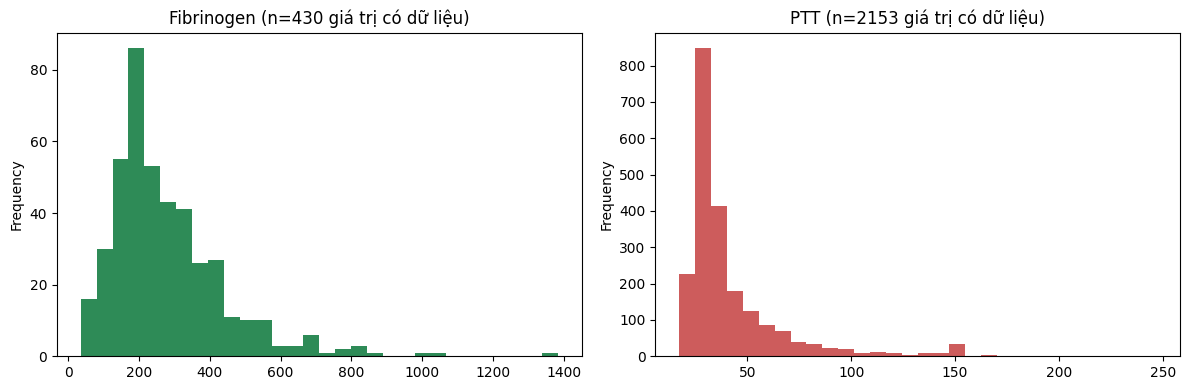

In [3]:
# Nhãn SepsisLabel ở cấp độ bệnh nhân (từng có giờ nào SepsisLabel=1 chưa) + phân phối Fibrinogen/PTT khi có giá trị
per_patient = []
for f in sample_files:
    d = pd.read_csv(f, sep='|')
    per_patient.append({'file': f.name, 'Age': d['Age'].iloc[0], 'Gender': d['Gender'].iloc[0],
                         'ever_sepsis': int(d['SepsisLabel'].max()), 'n_hours': len(d)})
pp = pd.DataFrame(per_patient)
print('Tỷ lệ bệnh nhân từng có SepsisLabel=1 (trong mẫu 2000):')
print(pp['ever_sepsis'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
big['Fibrinogen'].dropna().plot.hist(ax=axes[0], bins=30, color='seagreen')
axes[0].set_title(f"Fibrinogen (n={big['Fibrinogen'].notna().sum()} giá trị có dữ liệu)")
big['PTT'].dropna().plot.hist(ax=axes[1], bins=30, color='indianred')
axes[1].set_title(f"PTT (n={big['PTT'].notna().sum()} giá trị có dữ liệu)")
plt.tight_layout()
plt.show()

## Nhận xét

- Dữ liệu time-series đa biến, **tỷ lệ missing rất cao** ở nhiều chỉ số xét nghiệm (Fibrinogen, PTT, Bilirubin thường chỉ đo khi bác sĩ chỉ định, không phải mỗi giờ) — cần chiến lược xử lý riêng (lấy giá trị gần nhất/forward-fill, hoặc chỉ giữ các dòng có đo xét nghiệm) trước khi coi là dữ liệu bảng tĩnh.
- Đây là nguồn **duy nhất** trong kho có Fibrinogen/PTT (đông máu) — dù thưa dữ liệu vẫn là nguồn quý.
- Nhãn `SepsisLabel` là nhiễm trùng huyết, không phải bệnh lý huyết học mục tiêu — chỉ dùng làm nguồn bổ sung, không dùng làm nhãn chính.
- 100% trong số 40.336 file đã được xác minh không rỗng/hỏng khi tải (xem `Data/README.md`).